# First research question

**RESEARCH QUESTION: Among the active transaction-covered topics, does prior practice and performance on sibling topics help predict better a user's success when they first enter a new child topic, beyond the student’s general prior ability?**

**METHOD:** For each user_id-child_topic_id pair, identify the first 3 eligible attempts on that child topic (this is the moment the user starts the topic and whether they succeed or not at entry), and test whether previous exposure to the sibling topics is associated with higher correctness on those first attempts.

GOAL = interpretation of the effect of prior parent/sibling practice

**MOTIVATION:** This study investigates the principle of "transfer of learning" and helps answer whether some topics should be practiced before others, whether the hierarchy reflects real prerequisite relations and whether moving a student to a child topic too early harms their performance.

If prior practice clearly helps on first attempts, the company Lernnavi could use that to design prerequisite recommendations and more adaptive onboarding into a new topic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

DATA_DIR = './Lernnavi'

users = pd.read_csv('{}/users.csv.gz'.format(DATA_DIR))
events = pd.read_csv('{}/events.csv.gz'.format(DATA_DIR))
transactions = pd.read_csv('{}/transactions.csv.gz'.format(DATA_DIR))
documents = pd.read_csv('{}/documents.csv.gz'.format(DATA_DIR))
topic_trees = pd.read_csv('{}/topic_trees.csv.gz'.format(DATA_DIR))
topics = pd.read_csv('{}/topics_translated.csv'.format(DATA_DIR))
feedback = pd.read_csv('{}/feedback.csv.gz'.format(DATA_DIR))

# Important conclusions from data exploration (important context for the rest of this notebook)

- The dataset contains a curriculum organized in a tree with parent and children topics (the hierarchy is given by `topic_trees`). The hierarchy has root topics (no parent), leaf topics (no children) and intermediate topics.
- Topics cover 2 subjects (german and math) which is tracked via the `math` flag.
- Only 76 out of the 700 initial topics actually appear in the `transactions` logs and account for 1,268,894 transactions. The rest have 0 user activity.
- 73 of the 76 active topics have at least one active sibling (= another topic sharing the same parent), forming 14 sibling groups (and represent **1,262,244 transactions**).
- German topics have more interactions than Math topics overall.
- There are 19,489 users in total, but they dropout really easily. When we remove users with less than 2 active weeks, the mean number of active weeks per retained user is approx. 3.84 weeks

The dataset is therefore sufficient to treat this question.

**Note:** All these values will also appear as outputs in various cells below.

# 1) Data cleaning and preprocessing

**a) Defining the study universe**

Starting topic set should be:

- valid topics only *(in the dataset description pdf, they say some topics have messages in their "description" that explicitly say they are unusable/deleted etc, so we remove them)*
- connected to the clean hierarchy *(we verify they appear in `topic_tree`)*
- active in transactions
- non-root *(we remove the roots "german" and "maths")*
- with at least one active sibling

**b) Target definition and design choices**

- We define "entering a new child topic" by the correctness score from the first 3 answered questions on that child topic *(we assume this is less noisy than the 1st answered question alone)*
- The variable we'll use is `evaluation` (which can take these values: CORRECT / WRONG / PARTIAL / NAN)
- The potential classes of the target are therefore "0/3", "1/3", "2/3" or "3/3" of correctness score on the first 3 answered questions per user-topic pair. However, we observe that the distribution is very unbalanced and "0/3" represents ...% among all classes. Therefore, we merge "0/3" and "1/3" scores to represent "early difficulty", and we keep "2/3" representing "early moderate success" and "3/3" as "early perfect success", resulting in 3 classes.
- entry_target_df : is the target-level table with one row per (`user_id`, `child_topic_id`) entry event.

**c) Cleaning the universe**

We exclude:

- transactions with topic_id = NaN *(they are not answered questions)*
- challenge activity *(because the goal of this study is the learning journey, so we focus on "normal" learning)* 
- users with missing timestamps *(if `commit_time` is NaN, it means the answer to the question was never submitted and therefore was not evaluated)*
- for the `evaluation` variable: we only keep correct = 1, wrong = 0, but we exclude NaNs and "PARTIAL" as it is unclear how to treat them since it is quite task-type dependent (some question formats naturally allow partial credit but others do not), which could mix learning signal with artifact from the question format.
- we exclude user-topic pairs with less than 3 answered questions (and the target is computed from the first 3 answered questions).

Then, we reorder the dataset: the remaining rows from `transactions` that represent (user_id, child_topic_id) pairs ordered chronologically using start_time

**d) Building the hierarchical mapping**

We map each active child topic to its `parent_id` and sibling set in a look-up table with these columns:

- child_topic_id
- parent_id
- child_name
- parent_name
- sibling_topic_ids (set)

this will help compute prior related-topic exposure.

**VISUALIZATIONS:** coverage:

- number of entry events per child topic
- number of users per child topic
- distribution of prior sibling exposure at topic entry

In [2]:
# a) Define the study universe

# 1) keep valid topic only -> delete topics with messages in the description column containing the words: "deleted" "delete" "error" or "mistake"
print("------ VALID TOPIC SELECTION ------")
# Replace NaN description by empty comment (they are kept because it does not mean the topic is invalid)
topics["description"] = topics["description"].fillna("").str.strip()

# Regex patterns for invalid topics
invalid_patterns = [
    r"\bdelete?\b",      
    r"\bdeleted?\b",    
    r"\berror\b",   
    r"\bmistake\b",  
    r"\binvalid\b"  
]

invalid_regex = "|".join(invalid_patterns)

# New column created: is invalid -> flag invalid topics with "True" value in this new column
topics["is_invalid"] = topics["description"].str.lower().str.contains(
    invalid_regex,
    regex=True,
    na=False
)

# keep only the valid topics in a new table valid_topics
valid_topics = topics.loc[~topics["is_invalid"]].copy()

print("Number of invalid topics detected:", topics["is_invalid"].sum())
print("Number of valid topics:", len(valid_topics))

# 2) keep only topics present in the tree
print("------ ONLY KEEP TOPICS PRESENT IN TH TREE ------")
# only keep valid topics that were found before on topics table from the topic_trees file also
mask_valid_hierarchy = (
    topic_trees["child_id"].isin(set(valid_topics["id"]))
    & (topic_trees["parent_id"].isna() | topic_trees["parent_id"].isin(set(valid_topics["id"])))
)

tree_valid = topic_trees.loc[mask_valid_hierarchy].copy() # cleaned hierarchy table
valid_topics_in_tree = set(tree_valid["child_id"].dropna().astype(int)).union(set(tree_valid["parent_id"].dropna().astype(int))) # cleaned set of topics present in the tree_valid table

print("Rows kept in valid hierarchy:", len(tree_valid))
print("Rows removed because child or parent topic was invalid:", len(topic_trees) - len(tree_valid))
print("Unique valid topics represented in the hierarchy:", len(valid_topics_in_tree))

# remove those missing topic in tree from the valid topics list
valid_topics = valid_topics[valid_topics["id"].isin(valid_topics_in_tree)].copy()
print("Number of usable valid topics after filtering:", valid_topics["id"].nunique())

# 3) keep only topics that appear in the transactions table
print("------ ONLY KEEP THE TOPICS THAT APPEAR IN THE TRANSACTIONS ------")
valid_topic_ids = set(valid_topics["id"].dropna().astype(int))

# keep only transactions on usable valid topics
transactions = transactions[transactions["topic_id"].isin(valid_topic_ids)].copy()
topics_seen_in_transactions = set(transactions["topic_id"].dropna().astype(int))

print("Transactions kept on usable valid topics:", len(transactions))
print("Number of usable valid topics represented in transactions:", transactions["topic_id"].nunique())

# remove those topics that never appear in the transactions table from the valid topics list
valid_topics = valid_topics[valid_topics["id"].isin(topics_seen_in_transactions)].copy()
valid_topic_ids = set(valid_topics["id"].dropna().astype(int))

print("Number of valid topics remaining after keeping only those seen in transactions:", valid_topics["id"].nunique())

# 4) keep only topics with at least one active sibling (which also removes root topics "german" and "maths")
print("------ KEEP ONLY TOPICS WITH AT LEAST 1 ACTIVE SIBLING ------")
child_parent = tree_valid[["child_id", "parent_id"]].drop_duplicates().copy()
child_parent["child_id"] = pd.to_numeric(child_parent["child_id"], errors="coerce")
child_parent["parent_id"] = pd.to_numeric(child_parent["parent_id"], errors="coerce")

# keep only active topics in the hierarchy
child_parent = child_parent[child_parent["child_id"].isin(valid_topic_ids)].copy()

# number of active children per parent
n_active_children = child_parent[child_parent["parent_id"].notna()].groupby("parent_id")["child_id"].nunique()

# topics whose parent has at least 2 active children (= at least one active sibling)
topics_with_active_siblings = set(
    child_parent.loc[
        child_parent["parent_id"].notna()
        & child_parent["parent_id"].map(n_active_children).fillna(0).ge(2),
        "child_id"
    ].astype(int)
)

# keep only those topics
valid_topics = valid_topics[valid_topics["id"].isin(topics_with_active_siblings)].copy()

# keep transactions consistent with the new topic universe (just in case)
transactions = transactions[transactions["topic_id"].isin(topics_with_active_siblings)].copy()

print("Number of active topics with at least one active sibling:", len(topics_with_active_siblings))
print("Number of valid topics remaining:", valid_topics["id"].nunique())
print("Transactions remaining:", len(transactions))

------ VALID TOPIC SELECTION ------
Number of invalid topics detected: 48
Number of valid topics: 652
------ ONLY KEEP TOPICS PRESENT IN TH TREE ------
Rows kept in valid hierarchy: 626
Rows removed because child or parent topic was invalid: 52
Unique valid topics represented in the hierarchy: 633
Number of usable valid topics after filtering: 633
------ ONLY KEEP THE TOPICS THAT APPEAR IN THE TRANSACTIONS ------
Transactions kept on usable valid topics: 1268894
Number of usable valid topics represented in transactions: 76
Number of valid topics remaining after keeping only those seen in transactions: 76
------ KEEP ONLY TOPICS WITH AT LEAST 1 ACTIVE SIBLING ------
Number of active topics with at least one active sibling: 73
Number of valid topics remaining: 73
Transactions remaining: 1262244


In [3]:
# b) cleaning the universe

# Make sure timestamps are datetime
transactions["start_time"] = pd.to_datetime(transactions["start_time"], errors="coerce")
transactions["commit_time"] = pd.to_datetime(transactions["commit_time"], errors="coerce")

# are there challenge activities remaining?
n_challenge = (transactions["challenge"] == True).sum()

# how many users have at least one missing timestamp?
users_missing_timestamps = transactions.loc[
    transactions["start_time"].isna() | transactions["commit_time"].isna(),
    "user_id"
].nunique()

print("Challenge activities in remaining transactions:", n_challenge)
print("Users with missing timestamps:", users_missing_timestamps) # those are task attempts that were started but never submitted (this represents 79,466 rows across 17,369 users) -> for this research question we need only answered question

# we remove transactions where one timestamp is missing
transactions = transactions[transactions["commit_time"].notna()].copy()
print("Remaining number of transactions:", len(transactions))

Challenge activities in remaining transactions: 0
Users with missing timestamps: 17369
Remaining number of transactions: 1182778


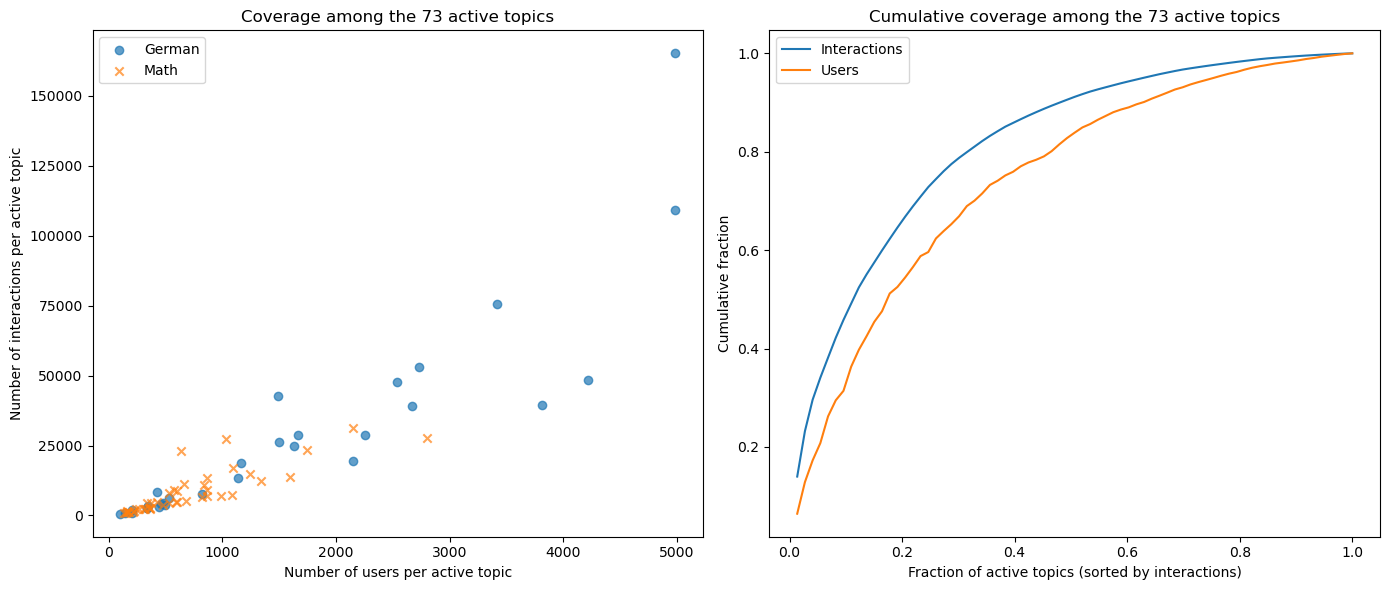

In [4]:
# VISUALIZATION: coverage among the remaining 73 topics

# prepare data
topic_user_stats_active = (
    transactions.groupby("topic_id")
    .agg(
        n_interactions=("topic_id", "size"),
        n_users=("user_id", "nunique")
    )
    .reset_index()
    .merge(
        valid_topics[["id", "name", "math"]],
        left_on="topic_id",
        right_on="id",
        how="left"
    )
    .drop(columns="id")
    .sort_values("n_interactions", ascending=False)
    .reset_index(drop=True)
)

coverage_curve_active = topic_user_stats_active.copy()
coverage_curve_active["topic_rank"] = np.arange(1, len(coverage_curve_active) + 1)

coverage_curve_active["cum_interactions"] = coverage_curve_active["n_interactions"].cumsum()
coverage_curve_active["cum_users"] = coverage_curve_active["n_users"].cumsum()

coverage_curve_active["cum_interactions_frac"] = (
    coverage_curve_active["cum_interactions"] / coverage_curve_active["n_interactions"].sum()
)
coverage_curve_active["cum_users_frac"] = (
    coverage_curve_active["cum_users"] / coverage_curve_active["n_users"].sum()
)
coverage_curve_active["topic_frac"] = (
    coverage_curve_active["topic_rank"] / len(coverage_curve_active)
)

# Create one figure with 2 panels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_df = topic_user_stats_active.copy()
for m, label, marker in [(0, "German", "o"), (1, "Math", "x")]:
    subset = plot_df[plot_df["math"] == m]
    axes[0].scatter(
        subset["n_users"],
        subset["n_interactions"],
        alpha=0.7,
        label=label,
        marker=marker
    )

axes[0].set_xlabel("Number of users per active topic")
axes[0].set_ylabel("Number of interactions per active topic")
axes[0].set_title("Coverage among the 73 active topics")
axes[0].legend()

axes[1].plot(
    coverage_curve_active["topic_frac"],
    coverage_curve_active["cum_interactions_frac"],
    label="Interactions"
)
axes[1].plot(
    coverage_curve_active["topic_frac"],
    coverage_curve_active["cum_users_frac"],
    label="Users"
)

axes[1].set_xlabel("Fraction of active topics (sorted by interactions)")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Cumulative coverage among the 73 active topics")
axes[1].legend()

plt.tight_layout()
plt.show()

**IMPORTANT CONCLUSION FROM THESE PLOTS:** Some topics are very well represented (lots of users have answered questions associated with these topics and/or many questions from these topics were answered) and will contribute a lot to the model, while others are very sparse. The model will therefore learn much more reliably on the large topics and performance on small topics may be unstable.

Number of CORRECT transactions: 490366
Number of WRONG transactions: 125496


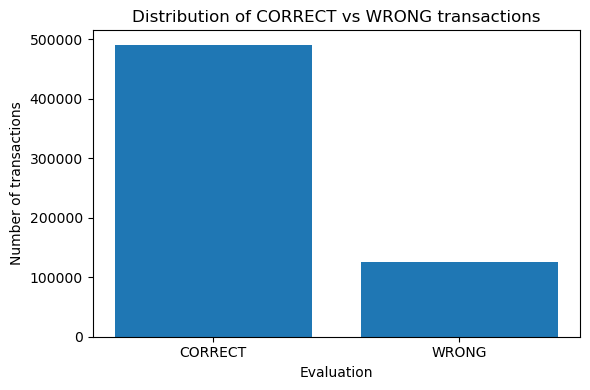

In [5]:
# c) Target variable

# Keep only rows with a strict outcome (either CORRECT or WRONG, we exclude NaNs and PARTIAL answers)
transactions = transactions[transactions["evaluation"].isin(["CORRECT", "WRONG"])].copy()

# binary target column
transactions["target"] = (transactions["evaluation"] == "CORRECT").astype(int)

# Print total number of transactions for each class
class_counts = transactions["evaluation"].value_counts()
print("Number of CORRECT transactions:", class_counts.get("CORRECT", 0))
print("Number of WRONG transactions:", class_counts.get("WRONG", 0))

# Plot distribution of each class
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Evaluation")
plt.ylabel("Number of transactions")
plt.title("Distribution of CORRECT vs WRONG transactions")
plt.tight_layout()
plt.show()

In [6]:
# Reorder the dataset and define what is the "first attempts in a new child topics"

# FIRST I NEED TO VERIFY WE CAN DEFINE "ENTERING A NEW CHILD TOPIC" AS THE CORRECTNESS SCORE OF THE FIRST 3 ANSWERED QUESTIONS
# Count answered questions per user per child topic
user_topic_counts = (
    transactions.groupby(["user_id", "topic_id"])
    .size()
    .reset_index(name="n_answered_questions")
)

# distribution of number of answered questions per user-topic pair
print("\nSummary of answered questions per user-topic pair:")
print(user_topic_counts["n_answered_questions"].describe())

# keep user-topic pairs with at least 3 answered questions and check there are enough pairs remaining
user_topic_3plus = user_topic_counts[user_topic_counts["n_answered_questions"] >= 3].copy()

print("Number of user-topic pairs:", len(user_topic_counts))
print("Number of user-topic pairs with at least 3 answered questions:", len(user_topic_3plus))
print("Proportion:", len(user_topic_3plus) / len(user_topic_counts))

# okay let's keep the first 3 questions which is robust to describe an "entry phase" into a subject
# we merge 0/3 and 1/3 as "the student is not entering the topic smoothly and seems to have real difficulty early on" and keep 2/3 (moderate success) and 3/3 (strong success) options => 3 classes

# Keep only the columns we need and sort chronologically within each (user, topic) pair
tx_target = transactions.copy()
sort_cols = [c for c in ["user_id", "topic_id", "start_time", "commit_time", "transaction_id"] if c in tx_target.columns]
tx_target = tx_target.sort_values(sort_cols).copy()

# Rank answered questions within each (user_id, child_topic_id) pair
tx_target["question_rank_in_topic"] = tx_target.groupby(["user_id", "topic_id"]).cumcount() + 1

# Keep only the first 3 answered questions per (user_id, child_topic_id)
tx_first3 = tx_target[tx_target["question_rank_in_topic"] <= 3].copy()

# Aggregate to one row per (user_id, child_topic_id)
entry_target_df = (
    tx_first3.groupby(["user_id", "topic_id"], as_index=False)
    .agg(
        n_first_questions=("evaluation", "size"),
        n_correct_first3=("evaluation", lambda s: (s == "CORRECT").sum()),
        first_start_time=("start_time", "min"),
        first_commit_time=("commit_time", "min")
    )
)

# keep only user-topic pairs with at least 3 answered questions, and keep only the answers to the first 3 questions
entry_target_df = entry_target_df[entry_target_df["n_first_questions"] == 3].copy()

# Define the target classes
# difficulty = 0/3 or 1/3 correct
# moderate_success = 2/3 correct
# strong_success = 3/3 correct
entry_target_df["target_class"] = np.select(
    [entry_target_df["n_correct_first3"].isin([0, 1]), entry_target_df["n_correct_first3"] == 2, entry_target_df["n_correct_first3"] == 3],
    ["difficulty", "moderate_success", "strong_success"],
    default="unknown"
)

# numeric encoding of classes for modeling
target_map = {
    "difficulty": 0,
    "moderate_success": 1,
    "strong_success": 2
}
entry_target_df["target_code"] = entry_target_df["target_class"].map(target_map)


print("Number of user-topic pairs kept in the final target table:", len(entry_target_df))
print("\nTarget distribution:")
print(entry_target_df["target_class"].value_counts())
print("\nTarget proportions:")
print(entry_target_df["target_class"].value_counts(normalize=True))

display(entry_target_df.head(20))


Summary of answered questions per user-topic pair:
count    67711.000000
mean         9.095450
std         34.319466
min          1.000000
25%          2.000000
50%          5.000000
75%         10.000000
max       6930.000000
Name: n_answered_questions, dtype: float64
Number of user-topic pairs: 67711
Number of user-topic pairs with at least 3 answered questions: 49735
Proportion: 0.7345187635686964
Number of user-topic pairs kept in the final target table: 49735

Target distribution:
target_class
strong_success      26316
moderate_success    15557
difficulty           7862
Name: count, dtype: int64

Target proportions:
target_class
strong_success      0.529124
moderate_success    0.312798
difficulty          0.158078
Name: proportion, dtype: float64


,user_id,topic_id,n_first_questions,n_correct_first3,first_start_time,first_commit_time,target_class,target_code
0,387604,3.0,3,2,2021-09-01 07:23:37.360,2021-09-01 07:23:53.904000000,moderate_success,1
2,387604,2055.0,3,2,2022-03-21 09:59:59.304,2022-03-21 10:00:04.163000064,moderate_success,1
3,387604,2064.0,3,3,2022-08-23 10:55:57.570,2022-08-23 10:56:19.006000128,strong_success,2
4,387604,2065.0,3,3,2022-08-30 10:56:18.126,2022-08-30 10:56:45.919000064,strong_success,2
5,387604,3113.0,3,3,2022-05-11 13:02:48.592,2022-05-11 13:03:21.601999872,strong_success,2
6,387604,3156.0,3,3,2022-05-11 12:39:31.001,2022-05-11 12:40:32.768999936,strong_success,2
8,387604,3250.0,3,1,2022-03-30 11:26:59.620,2022-03-30 11:27:59.465999872,difficulty,0
9,387605,3.0,3,3,2021-09-05 03:35:49.950,2021-09-05 03:36:03.064000000,strong_success,2
11,387605,956.0,3,1,2021-09-05 03:17:41.084,2021-09-05 03:17:55.377999872,difficulty,0
12,387605,957.0,3,1,2022-05-10 06:57:41.153,2022-05-10 06:58:34.694000128,difficulty,0


In [7]:
# Final modeling data summary
print("Final modeling dataframe shape:", entry_target_df.shape)
print("Number of entry events (rows):", len(entry_target_df))
print("Number of unique users:", entry_target_df["user_id"].nunique())

print("\nTarget proportions:")
print(entry_target_df["target_class"].value_counts(normalize=True))

print("\nRows per child topic:")
print(entry_target_df.groupby("topic_id").size().describe())

print("\nRows per user:")
print(entry_target_df.groupby("user_id").size().describe())

Final modeling dataframe shape: (49735, 8)
Number of entry events (rows): 49735
Number of unique users: 14938

Target proportions:
target_class
strong_success      0.529124
moderate_success    0.312798
difficulty          0.158078
Name: proportion, dtype: float64

Rows per child topic:
count      73.000000
mean      681.301370
std       822.954445
min        17.000000
25%       170.000000
50%       397.000000
75%       804.000000
max      3986.000000
dtype: float64

Rows per user:
count    14938.000000
mean         3.329428
std          3.464680
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         40.000000
dtype: float64


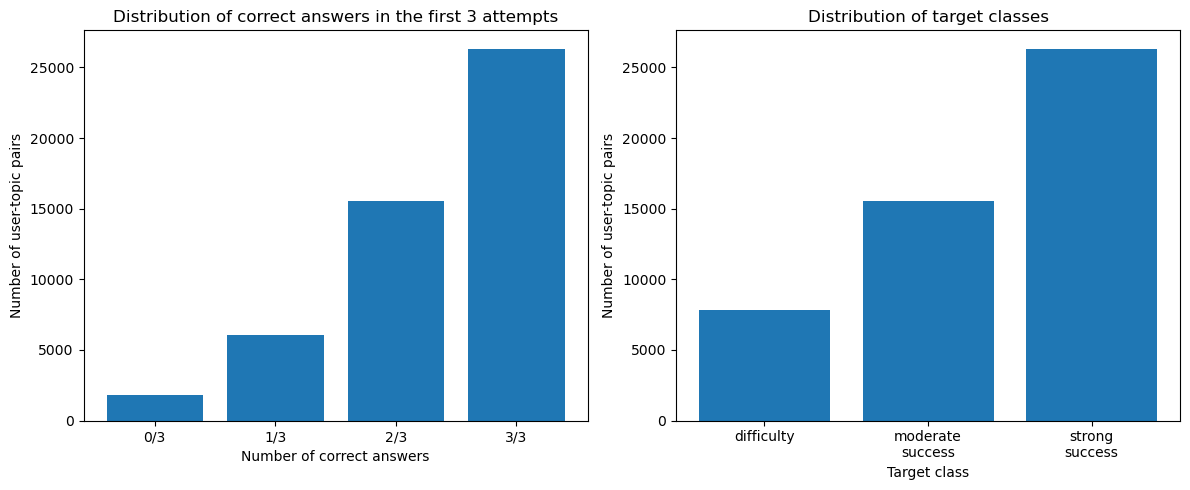

In [8]:
# count distribution of number of correct answers among the first 3
counts_first3 = (
    entry_target_df["n_correct_first3"]
    .value_counts()
    .reindex([0, 1, 2, 3], fill_value=0)
)

# count distribution of target classes
class_order = ["difficulty", "moderate_success", "strong_success"]
counts_classes = (
    entry_target_df["target_class"]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

# create one figure representing both distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    ["0/3", "1/3", "2/3", "3/3"],
    counts_first3.values
)
axes[0].set_title("Distribution of correct answers in the first 3 attempts")
axes[0].set_xlabel("Number of correct answers")
axes[0].set_ylabel("Number of user-topic pairs")

axes[1].bar(
    ["difficulty", "moderate\nsuccess", "strong\nsuccess"],
    counts_classes.values
)
axes[1].set_title("Distribution of target classes")
axes[1].set_xlabel("Target class")
axes[1].set_ylabel("Number of user-topic pairs")

plt.tight_layout()
plt.show()

In [9]:
# d) Create a lookup table to map each active child topic to its parent_id and sibling set

# prepare a clean hierarchy restricted to the final retained topics
active_topic_ids = set(valid_topics["id"].dropna().astype(int))

hier_active = tree_valid.copy()
hier_active["child_id"] = pd.to_numeric(hier_active["child_id"], errors="coerce")
hier_active["parent_id"] = pd.to_numeric(hier_active["parent_id"], errors="coerce")

# keep only rows whose child is one of the final active topics
hier_active = hier_active[hier_active["child_id"].isin(active_topic_ids)].copy()

print("Rows in tree_valid:", len(tree_valid))
print("Rows in active hierarchy:", len(hier_active))
print("Unique active child topics in hierarchy:", hier_active["child_id"].nunique())
print("Unique active topics in valid_topics:", valid_topics["id"].nunique())

# add topic names
topic_lookup = topics[topics["id"].isin(valid_topics_in_tree)][["id", "name"]].drop_duplicates()

child_parent_named = (
    hier_active[["child_id", "parent_id"]]
    .drop_duplicates()
    .merge(
        topic_lookup.rename(columns={"id": "child_id", "name": "child_name"}),
        on="child_id",
        how="left"
    )
    .merge(
        topic_lookup.rename(columns={"id": "parent_id", "name": "parent_name"}),
        on="parent_id",
        how="left"
    )
)

# build sibling sets from shared parent
siblings_by_parent = (
    child_parent_named.groupby("parent_id")["child_id"]
    .apply(lambda s: sorted(s.dropna().astype(int).unique().tolist()))
    .reset_index(name="all_children_of_parent")
)

lookup_table = child_parent_named.merge(siblings_by_parent, on="parent_id", how="left")

# remove the child itself from its sibling set
lookup_table["sibling_topic_ids"] = lookup_table.apply(
    lambda row: [tid for tid in row["all_children_of_parent"] if tid != row["child_id"]],
    axis=1
)

lookup_table["n_active_siblings"] = lookup_table["sibling_topic_ids"].apply(len)

lookup_table = lookup_table[
    ["child_id", "parent_id", "child_name", "parent_name", "sibling_topic_ids", "n_active_siblings"]
].rename(columns={
    "child_id": "child_topic_id"
})

print("\nLookup table rows:", len(lookup_table))

display(lookup_table.head(20))

Rows in tree_valid: 626
Rows in active hierarchy: 73
Unique active child topics in hierarchy: 73
Unique active topics in valid_topics: 73

Lookup table rows: 73


,child_topic_id,parent_id,child_name,parent_name,sibling_topic_ids,n_active_siblings
0,3,2.0,Spelling principles,Orthography,"[2055, 2064, 2065]",3
1,2055,2.0,Upper and lower case,Orthography,"[3, 2064, 2065]",3
2,2064,2.0,Separation and combination,Orthography,"[3, 2055, 2065]",3
3,2065,2.0,Spelling difficult words,Orthography,"[3, 2055, 2064]",3
4,2023,2022.0,Vocabulary,Vocabulary and stylistics,"[2042, 2045, 2048]",3
5,2042,2022.0,Idiomatisms,Vocabulary and stylistics,"[2023, 2045, 2048]",3
6,2045,2022.0,Rhetoric,Vocabulary and stylistics,"[2023, 2042, 2048]",3
7,2048,2022.0,Stylistic appropriateness,Vocabulary and stylistics,"[2023, 2042, 2045]",3
8,951,950.0,Number sets,Numbers and number sets,"[952, 956, 957, 958, 962, 963, 964, 968]",8
9,952,950.0,Fractions - basic arithmetic operations,Numbers and number sets,"[951, 956, 957, 958, 962, 963, 964, 968]",8


In [10]:
# set of child topics in the final lookup table
child_topic_ids = set(lookup_table["child_topic_id"].dropna().astype(int))

# set of parent topics in the final lookup table
parent_topic_ids = set(lookup_table["parent_id"].dropna().astype(int))

# parents that are also child topics
parents_also_children = parent_topic_ids.intersection(child_topic_ids)

print("Number of unique parent topics in the final lookup table:", len(parent_topic_ids))
print("Number of parent topics that are also child topics:", len(parents_also_children))

Number of unique parent topics in the final lookup table: 14
Number of parent topics that are also child topics: 0


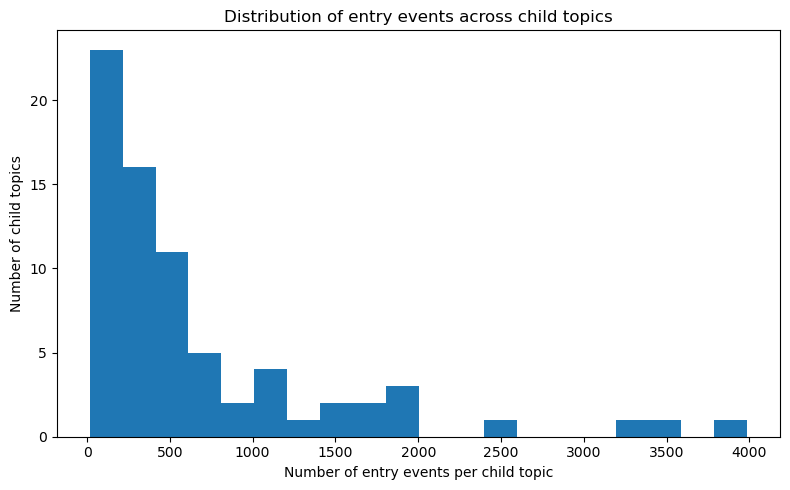

In [11]:
# visu: number of entry events and/or users per child topic

entry_plot_df = entry_target_df.rename(columns={"topic_id": "child_topic_id"}).copy()

# Count entry events per child topic
entry_counts = (
    entry_plot_df.groupby("child_topic_id")
    .size()
    .reset_index(name="n_entry_events")
    .merge(
        lookup_table[["child_topic_id", "child_name", "parent_name"]],
        on="child_topic_id",
        how="left"
    )
    .sort_values("n_entry_events", ascending=False)
)

# Histogram of entry-event counts across child topics
plt.figure(figsize=(8, 5))
plt.hist(entry_counts["n_entry_events"], bins=20)
plt.xlabel("Number of entry events per child topic")
plt.ylabel("Number of child topics")
plt.title("Distribution of entry events across child topics")
plt.tight_layout()
plt.show()

# 2) Feature engineering & creation of the final modeling dataframe

/!\ for each entry event (user, child topic, entry time), the features are computed **ONLY FROM TRANSACTIONS STRICTLY EARLIER THAN THE ENTRY TIME** /!\

**a) Baseline features:**

to isolate the sibling effect, we first try to capture the user's general ability and experience before entering the new topic through the following features:

- total number of prior answered questions
- global prior accuracy
- prior subject-specific experience (german or math)
- recency since last platform activity
- prior number of active weeks
- number of previously seen topics (in general)
- prior number of topics in the same subject (german or math)
- prior subject-specific accuracy

These features are computed from all prior answered questions in the final 73-topic universe, even if they don't belong to the user-topic pairs in the target table `entry_target_df`.

and for each (user, child topic) pair, we add these last features to separate hierarchy effects from topic-specific difficulty:

- child topic ID
- subject (math or german)

**b) Hierarchical features:**

**SIBLING TOPIC FEATURES:** before the first attempt on child topic, we compute the following features:

- number of prior attempts on sibling topics
- prior accuracy on sibling topics
- number of distinct sibling topics already practiced
- recency since last sibling practice
- proportion of siblings already seen

**PARENT-TOPIC FEATURES:** no feature related to parent-topic can be engineered since no transaction was recorded for parent topics in the raw transactions table (see the cell after the creation of the lookup table above (part d)).

**FINAL MODELING DATAFRAME:** `entry_model_df` : one row per user-topic entry with 1 column per feature

**Clean the modeling dataframe:** For each row, we verified the chronology to ensure it is not broken and we previously removed rows with missing target. NaN values in features are handled differently depending on the feature (see in the cells below for details).

**VISUALIZATION:** descriptive plots:

- distribution of prior sibling exposure at topic entry
- success rate on 1st child-topic attempt vs nb of prior sibling topics seen
- success rate vs binned prior sibling accuracy
- success rate vs prior parent-branch practice

In [12]:
# BASELINE FEATURES

# 1) Prepare transaction-level table with topic metadata
tx_feat = transactions.copy() 

# add child topic metadata
tx_feat = tx_feat.merge(
    valid_topics[["id", "name", "math"]].rename(columns={
        "id": "topic_id",
        "name": "child_name",
        "math": "subject_math"
    }),
    on="topic_id",
    how="left"
)

# binary correctness for prior-accuracy features
tx_feat["is_correct"] = (tx_feat["evaluation"] == "CORRECT").astype(int)

# sort chronologically within user
sort_cols = [c for c in ["user_id", "start_time", "commit_time", "transaction_id"] if c in tx_feat.columns]
tx_feat = tx_feat.sort_values(sort_cols).copy()

# 2) Transaction-level cumulative features BEFORE each transaction

# total number of prior answered questions
tx_feat["n_prior_answered_questions"] = tx_feat.groupby("user_id").cumcount()

# global prior accuracy
tx_feat["prior_correct_sum_global"] = tx_feat.groupby("user_id")["is_correct"].cumsum() - tx_feat["is_correct"]
tx_feat["prior_global_accuracy"] = (
    tx_feat["prior_correct_sum_global"] /
    tx_feat["n_prior_answered_questions"].replace(0, np.nan)
)

# prior subject-specific experience
tx_feat["n_prior_answered_same_subject"] = tx_feat.groupby(["user_id", "subject_math"]).cumcount()

tx_feat["prior_correct_sum_same_subject"] = (
    tx_feat.groupby(["user_id", "subject_math"])["is_correct"].cumsum() - tx_feat["is_correct"]
)

tx_feat["prior_subject_accuracy"] = (
    tx_feat["prior_correct_sum_same_subject"] /
    tx_feat["n_prior_answered_same_subject"].replace(0, np.nan)
)

# recency since last platform activity
tx_feat["prev_activity_time"] = tx_feat.groupby("user_id")["start_time"].shift(1)
tx_feat["days_since_last_activity"] = (
    (tx_feat["start_time"] - tx_feat["prev_activity_time"]).dt.total_seconds() / 86400
)

# recency since last same-subject activity
tx_feat["prev_same_subject_activity_time"] = (
    tx_feat.groupby(["user_id", "subject_math"])["start_time"].shift(1)
)

tx_feat["days_since_last_same_subject_activity"] = (
    (tx_feat["start_time"] - tx_feat["prev_same_subject_activity_time"]).dt.total_seconds() / 86400
)

# Prior number of active weeks
# relative week index per user
user_week0 = tx_feat.groupby("user_id")["start_time"].transform("min")
tx_feat["week"] = ((tx_feat["start_time"] - user_week0).dt.days // 7).astype(int)

# one row per active week per user
user_week = (
    tx_feat[["user_id", "week"]]
    .drop_duplicates()
    .sort_values(["user_id", "week"])
    .copy()
)

# number of ACTIVE weeks before the current week
user_week["n_prior_active_weeks"] = user_week.groupby("user_id").cumcount()

# merge back to transactions
tx_feat = tx_feat.merge(user_week, on=["user_id", "week"], how="left")

# Prior number of previously seen topics (in general) and prior number of previously seen topics in the same subject (german vs math)

# first time each user sees each topic
first_topic_seen = (
    tx_feat.groupby(["user_id", "topic_id", "subject_math"], as_index=False)["start_time"]
    .min()
    .rename(columns={"start_time": "first_topic_seen_time"})
)

# ---- overall previously seen topics
topic_starts_overall = (
    first_topic_seen.groupby(["user_id", "first_topic_seen_time"])
    .size()
    .reset_index(name="n_new_topics_at_time")
    .sort_values(["user_id", "first_topic_seen_time"])
)

topic_starts_overall["cum_topics_seen"] = topic_starts_overall.groupby("user_id")["n_new_topics_at_time"].cumsum()
topic_starts_overall["n_prior_topics_seen"] = (
    topic_starts_overall.groupby("user_id")["cum_topics_seen"].shift(fill_value=0)
)

first_topic_seen = first_topic_seen.merge(
    topic_starts_overall[["user_id", "first_topic_seen_time", "n_prior_topics_seen"]],
    on=["user_id", "first_topic_seen_time"],
    how="left"
)

# ---- previously seen topics in the same subject (german or math)
topic_starts_same_subject = (
    first_topic_seen.groupby(["user_id", "subject_math", "first_topic_seen_time"])
    .size()
    .reset_index(name="n_new_same_subject_topics_at_time")
    .sort_values(["user_id", "subject_math", "first_topic_seen_time"])
)

topic_starts_same_subject["cum_same_subject_topics_seen"] = (
    topic_starts_same_subject.groupby(["user_id", "subject_math"])["n_new_same_subject_topics_at_time"].cumsum()
)

topic_starts_same_subject["n_prior_topics_same_subject"] = (
    topic_starts_same_subject.groupby(["user_id", "subject_math"])["cum_same_subject_topics_seen"].shift(fill_value=0)
)

first_topic_seen = first_topic_seen.merge(
    topic_starts_same_subject[["user_id", "subject_math", "first_topic_seen_time", "n_prior_topics_same_subject"]],
    on=["user_id", "subject_math", "first_topic_seen_time"],
    how="left"
)

# extract the FIRST transaction row for each (user, topic) because entry features must be measured at topic entry
first_tx_per_user_topic = (
    tx_feat.groupby(["user_id", "topic_id"], as_index=False)
    .first()
    .rename(columns={
        "topic_id": "child_topic_id",
        "start_time": "entry_start_time",
        "commit_time": "entry_commit_time"
    })
)

# keep only the pre-entry features you want
first_tx_features = first_tx_per_user_topic[[
    "user_id",
    "child_topic_id",
    "entry_start_time",
    "entry_commit_time",
    "child_name",
    "subject_math",
    "n_prior_answered_questions",
    "prior_global_accuracy",
    "n_prior_active_weeks",
    "n_prior_answered_same_subject",
    "prior_subject_accuracy",
    "days_since_last_activity",
    "days_since_last_same_subject_activity"
]].copy()

# rename topic_id to child_topic_id for clarity
first_topic_seen = first_topic_seen.rename(columns={"topic_id": "child_topic_id"})

# for each entry event (user, child_topic) add the counts of how many topics the user had seen before entering the topic
first_tx_features = first_tx_features.merge(
    first_topic_seen[[
        "user_id",
        "child_topic_id",
        "n_prior_topics_seen",
        "n_prior_topics_same_subject"
    ]],
    on=["user_id", "child_topic_id"],
    how="left"
)

# 3) Build the final baseline features dataframe

# rename target table column for clarity
entry_model_df = entry_target_df.rename(columns={"topic_id": "child_topic_id"}).copy()

# merge lookup table (parent + siblings)
entry_model_df = entry_model_df.merge(
    lookup_table,
    on="child_topic_id",
    how="left"
)

# merge basic pre-entry features
entry_model_df = entry_model_df.merge(
    first_tx_features,
    on=["user_id", "child_topic_id"],
    how="left"
)

# 4) cleanup: fill missing feature values

# missing prior accuracies mean no prior history yet -> = 0
entry_model_df["prior_global_accuracy"] = entry_model_df["prior_global_accuracy"].fillna(0)
entry_model_df["prior_subject_accuracy"] = entry_model_df["prior_subject_accuracy"].fillna(0)

# no prior activity encoded by "-1"
entry_model_df["days_since_last_activity"] = entry_model_df["days_since_last_activity"].fillna(-1)
entry_model_df["days_since_last_same_subject_activity"] = (
    entry_model_df["days_since_last_same_subject_activity"].fillna(-1)
)

for col in [
    "n_prior_answered_questions",
    "n_prior_active_weeks",
    "n_prior_topics_seen",
    "n_prior_topics_same_subject",
    "n_prior_answered_same_subject"
]:
    entry_model_df[col] = entry_model_df[col].fillna(0).astype(int)

# final features: indicators
entry_model_df["has_prior_platform_activity"] = (entry_model_df["n_prior_answered_questions"] > 0).astype(int)
entry_model_df["has_prior_subject_activity"] = (entry_model_df["n_prior_answered_same_subject"] > 0).astype(int)

if "child_name_x" in entry_model_df.columns and "child_name_y" in entry_model_df.columns:
    entry_model_df["child_name"] = entry_model_df["child_name_x"].fillna(entry_model_df["child_name_y"])
    entry_model_df = entry_model_df.drop(columns=["child_name_x", "child_name_y"])

# 5) final feature selection -> we will only keep these ones for the baseline model training
baseline_features_cols = [
    "child_topic_id", # treated as a categorical variable, not numerical variable!
    "subject_math",
    "n_prior_answered_questions",
    "prior_global_accuracy",
    "n_prior_active_weeks",
    "n_prior_topics_seen",
    "n_prior_topics_same_subject",
    "n_prior_answered_same_subject",
    "prior_subject_accuracy",
    "days_since_last_activity",
    "days_since_last_same_subject_activity"
]

print("Final entry_model_df shape:", entry_model_df.shape)
print(entry_model_df.columns)
display(entry_model_df[baseline_features_cols].head(20))

Final entry_model_df shape: (49735, 27)
Index(['user_id', 'child_topic_id', 'n_first_questions', 'n_correct_first3',
       'first_start_time', 'first_commit_time', 'target_class', 'target_code',
       'parent_id', 'parent_name', 'sibling_topic_ids', 'n_active_siblings',
       'entry_start_time', 'entry_commit_time', 'subject_math',
       'n_prior_answered_questions', 'prior_global_accuracy',
       'n_prior_active_weeks', 'n_prior_answered_same_subject',
       'prior_subject_accuracy', 'days_since_last_activity',
       'days_since_last_same_subject_activity', 'n_prior_topics_seen',
       'n_prior_topics_same_subject', 'has_prior_platform_activity',
       'has_prior_subject_activity', 'child_name'],
      dtype='str')


,child_topic_id,subject_math,n_prior_answered_questions,prior_global_accuracy,n_prior_active_weeks,n_prior_topics_seen,n_prior_topics_same_subject,n_prior_answered_same_subject,prior_subject_accuracy,days_since_last_activity,days_since_last_same_subject_activity
0,3.0,0,0,0.000000,0,0,0,0,0.000000,201.106926,201.106926
1,2055.0,0,2,0.500000,1,1,1,2,0.500000,0.001661,0.001661
2,2064.0,0,48,0.875000,5,7,6,47,0.893617,1.139900,1.139900
3,2065.0,0,124,0.943548,6,8,7,123,0.951220,1.108403,1.108403
4,3113.0,0,14,0.714286,3,5,5,14,0.714286,0.007332,0.007332
5,3156.0,0,7,0.428571,3,3,3,7,0.428571,42.048944,42.048944
6,3250.0,0,3,0.333333,2,2,2,3,0.333333,9.060420,9.060420
7,3.0,0,57,0.736842,4,10,4,21,0.809524,0.001857,0.005326
8,956.0,1,36,0.805556,4,7,4,18,0.833333,7.466876,7.466876
9,957.0,1,77,0.792208,9,15,8,44,0.727273,34.989463,34.989463


In [13]:
# HIERARCHICAL SIBLING FEATURES

tx_hist = transactions.copy()
tx_hist["is_correct"] = (tx_hist["evaluation"] == "CORRECT").astype(int)
tx_hist = tx_hist.dropna(subset=["user_id", "topic_id", "start_time"]).copy()
tx_hist["topic_id"] = tx_hist["topic_id"].astype(int)

# 1) building sibling-level history before each entry event

entry_siblings = entry_model_df[
    ["user_id", "child_topic_id", "entry_start_time", "sibling_topic_ids", "n_active_siblings"]
].copy()

entry_siblings = entry_siblings.explode("sibling_topic_ids").rename(
    columns={"sibling_topic_ids": "sibling_topic_id"}
)

# make sure everything is in the right format
entry_siblings["sibling_topic_id"] = pd.to_numeric(entry_siblings["sibling_topic_id"], errors="coerce")
entry_siblings = entry_siblings.dropna(subset=["sibling_topic_id"]).copy()
entry_siblings["sibling_topic_id"] = entry_siblings["sibling_topic_id"].astype(int)

# match each entry event to past transactions on sibling topics
sib_hist = entry_siblings.merge(
    tx_hist[["user_id", "topic_id", "start_time", "is_correct"]],
    left_on=["user_id", "sibling_topic_id"],
    right_on=["user_id", "topic_id"],
    how="left"
)
# keep only transactions strictly before topic entry
sib_hist = sib_hist[sib_hist["start_time"] < sib_hist["entry_start_time"]].copy()
sib_hist["days_before_entry"] = ((sib_hist["entry_start_time"] - sib_hist["start_time"]).dt.total_seconds() / 86400)

# 2) overall sibling history features

sibling_features = (
    sib_hist.groupby(["user_id", "child_topic_id", "entry_start_time"], as_index=False)
    .agg(
        n_prior_sibling_attempts=("topic_id", "size"),
        prior_sibling_accuracy=("is_correct", "mean"),
        n_prior_sibling_topics_seen=("sibling_topic_id", "nunique"),
        last_sibling_activity_time=("start_time", "max")
    )
)

# recency since last sibling activity
sibling_features["days_since_last_sibling_activity"] = (
    (sibling_features["entry_start_time"] - sibling_features["last_sibling_activity_time"]).dt.total_seconds() / 86400
)

# 3) 30 day window features

sib_hist_30d = sib_hist[sib_hist["days_before_entry"] <= 30].copy()

sibling_features_30d = (
    sib_hist_30d.groupby(["user_id", "child_topic_id", "entry_start_time"], as_index=False)
    .agg(
        n_prior_sibling_attempts_30d=("topic_id", "size"),
        prior_sibling_accuracy_30d=("is_correct", "mean")
    )
)

# 4) last 3 sibling attempts features

# Recent sibling accuracy on the last 3 sibling attempts before entry
sib_hist_last3 = (
    sib_hist.sort_values(["user_id", "child_topic_id", "entry_start_time", "start_time"])
    .groupby(["user_id", "child_topic_id", "entry_start_time"], group_keys=False)
    .tail(3)
    .copy()
)

sibling_features_last3 = (
    sib_hist_last3.groupby(["user_id", "child_topic_id", "entry_start_time"], as_index=False)
    .agg(
        prior_sibling_accuracy_last3=("is_correct", "mean"),
        n_prior_sibling_attempts_last3=("is_correct", "size")
    )
)

# 5) merge all sibling features created  into entry_model_df
entry_model_df = entry_model_df.merge(
    sibling_features,
    on=["user_id", "child_topic_id", "entry_start_time"],
    how="left"
).merge(
    sibling_features_30d,
    on=["user_id", "child_topic_id", "entry_start_time"],
    how="left"
).merge(
    sibling_features_last3,
    on=["user_id", "child_topic_id", "entry_start_time"],
    how="left"
)

# 6) fill missing values
entry_model_df["n_prior_sibling_attempts"] = entry_model_df["n_prior_sibling_attempts"].fillna(0).astype(int)
entry_model_df["n_prior_sibling_topics_seen"] = entry_model_df["n_prior_sibling_topics_seen"].fillna(0).astype(int)
entry_model_df["prior_sibling_accuracy"] = entry_model_df["prior_sibling_accuracy"].fillna(0)
entry_model_df["days_since_last_sibling_activity"] = entry_model_df["days_since_last_sibling_activity"].fillna(-1)
entry_model_df["n_prior_sibling_attempts_30d"] = entry_model_df["n_prior_sibling_attempts_30d"].fillna(0).astype(int)
entry_model_df["prior_sibling_accuracy_30d"] = entry_model_df["prior_sibling_accuracy_30d"].fillna(0)
entry_model_df["prior_sibling_accuracy_last3"] = entry_model_df["prior_sibling_accuracy_last3"].fillna(0)
entry_model_df["n_prior_sibling_attempts_last3"] = entry_model_df["n_prior_sibling_attempts_last3"].fillna(0).astype(int)

# 7) derived sibling features

# Proportion of siblings already seen
entry_model_df["prop_siblings_seen"] = (
    entry_model_df["n_prior_sibling_topics_seen"] / entry_model_df["n_active_siblings"]
).fillna(0)

# Recent accuracy trend: recent sibling accuracy minus overall sibling accuracy
entry_model_df["recent_sibling_accuracy_trend"] = (
    entry_model_df["prior_sibling_accuracy_last3"] - entry_model_df["prior_sibling_accuracy"]
)

# 8) transition features within sibling group

# first-time transition features within the sibling group
# for each (user, parent), order the child-topic entries chronologically
entry_model_df = entry_model_df.sort_values(
    ["user_id", "parent_id", "entry_start_time", "child_topic_id"]
).copy()

entry_model_df["entry_rank_within_sibling_group"] = (
    entry_model_df.groupby(["user_id", "parent_id"]).cumcount() + 1
)

entry_model_df["n_prior_sibling_topics_entered"] = (
    entry_model_df["entry_rank_within_sibling_group"] - 1
)

entry_model_df["prop_sibling_topics_entered_before"] = (
    entry_model_df["n_prior_sibling_topics_entered"] / entry_model_df["n_active_siblings"]
).fillna(0)

entry_model_df["is_first_topic_in_sibling_group"] = (
    entry_model_df["entry_rank_within_sibling_group"] == 1
).astype(int)


sibling_features_cols = [
    "n_prior_sibling_attempts",
    "prior_sibling_accuracy",
    "days_since_last_sibling_activity",
    "prop_siblings_seen",
    "n_prior_sibling_attempts_30d",
    "prior_sibling_accuracy_30d",
    "prop_sibling_topics_entered_before",
    "is_first_topic_in_sibling_group",
    "prior_sibling_accuracy_last3",
    "n_prior_sibling_attempts_last3",
    "recent_sibling_accuracy_trend"
]

print("Sibling feature summary:")
display(entry_model_df[sibling_features_cols].describe())

display(
    entry_model_df[
        ["user_id", "child_topic_id", "entry_start_time", "n_active_siblings"] + sibling_features_cols
    ].head(20)
)

Sibling feature summary:


,n_prior_sibling_attempts,prior_sibling_accuracy,days_since_last_sibling_activity,prop_siblings_seen,n_prior_sibling_attempts_30d,prior_sibling_accuracy_30d,prop_sibling_topics_entered_before,is_first_topic_in_sibling_group,prior_sibling_accuracy_last3,n_prior_sibling_attempts_last3,recent_sibling_accuracy_trend
count,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000
mean,8.423404,0.380119,5.146296,0.220853,6.774786,0.346257,0.195768,0.556208,0.380353,1.366764,0.000234
std,19.441975,0.423433,29.291777,0.293481,15.862673,0.419690,0.277185,0.496836,0.441207,1.455185,0.121066
min,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.923077
25%,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,0.833333,0.004250,0.333333,7.000000,0.800000,0.333333,1.000000,1.000000,3.000000,0.000000
max,515.000000,1.000000,581.177513,1.000000,446.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.736842


,user_id,child_topic_id,entry_start_time,n_active_siblings,n_prior_sibling_attempts,prior_sibling_accuracy,days_since_last_sibling_activity,prop_siblings_seen,n_prior_sibling_attempts_30d,prior_sibling_accuracy_30d,prop_sibling_topics_entered_before,is_first_topic_in_sibling_group,prior_sibling_accuracy_last3,n_prior_sibling_attempts_last3,recent_sibling_accuracy_trend
0,387604,3.0,2021-09-01 07:23:37.360,3,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
1,387604,2055.0,2022-03-21 09:59:59.304,3,2,0.500000,0.001661,0.333333,1,1.000000,0.333333,0,0.500000,2,0.000000
2,387604,2064.0,2022-08-23 10:55:57.570,3,27,0.888889,1.139900,0.666667,24,0.958333,0.666667,0,1.000000,3,0.111111
3,387604,2065.0,2022-08-30 10:56:18.126,3,103,0.961165,1.108403,1.000000,100,0.980000,1.000000,0,1.000000,3,0.038835
4,387604,3113.0,2022-05-11 13:02:48.592,4,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
5,387604,3156.0,2022-05-11 12:39:31.001,3,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
6,387604,3250.0,2022-03-30 11:26:59.620,5,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
16,387605,2055.0,2021-07-09 12:25:12.063,3,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
17,387605,2064.0,2021-09-05 03:27:15.665,3,13,0.692308,57.620853,0.333333,0,0.000000,0.333333,0,0.666667,3,-0.025641
7,387605,3.0,2021-09-05 03:35:49.950,3,16,0.750000,0.005326,0.666667,3,1.000000,0.666667,0,1.000000,3,0.250000


# 3) Split the data (time-based split)

split by `entry_start_time` for the split to be chronological:

- earliest 70% = train
- next 15% = validation
- last 15% = test

In [14]:
# common chronological split for both models
model_df = entry_model_df.copy().sort_values("entry_start_time").reset_index(drop=True)

n = len(model_df)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_df = model_df.iloc[:train_end].copy()
val_df   = model_df.iloc[train_end:val_end].copy()
test_df  = model_df.iloc[val_end:].copy()

# shared target for both models
y_train = train_df["target_code"].copy()
y_val   = val_df["target_code"].copy()
y_test  = test_df["target_code"].copy()

# Baseline features
X_train_baseline = train_df[baseline_features_cols].copy()
X_val_baseline   = val_df[baseline_features_cols].copy()
X_test_baseline  = test_df[baseline_features_cols].copy()

# Hierarchical features
hierarchical_features_cols = baseline_features_cols + sibling_features_cols
X_train_hierarchical = train_df[hierarchical_features_cols].copy()
X_val_hierarchical   = val_df[hierarchical_features_cols].copy()
X_test_hierarchical  = test_df[hierarchical_features_cols].copy()

# Quick checks
print("Total rows:", n)
print("Train rows:", len(train_df), f"({len(train_df)/n:.2%})")
print("Validation rows:", len(val_df), f"({len(val_df)/n:.2%})")
print("Test rows:", len(test_df), f"({len(test_df)/n:.2%})")

print("\nTime ranges:")
print("Train:", train_df["entry_start_time"].min(), "->", train_df["entry_start_time"].max())
print("Validation:", val_df["entry_start_time"].min(), "->", val_df["entry_start_time"].max())
print("Test:", test_df["entry_start_time"].min(), "->", test_df["entry_start_time"].max())

Total rows: 49735
Train rows: 34814 (70.00%)
Validation rows: 7460 (15.00%)
Test rows: 7461 (15.00%)

Time ranges:
Train: 2021-05-21 10:20:53.223000 -> 2022-09-27 09:48:29.524000
Validation: 2022-09-27 09:48:33.173000 -> 2022-11-28 15:08:53.439000
Test: 2022-11-28 15:10:34.337000 -> 2023-02-05 21:56:40.929000


# 4) Models: definition, hyperparameter tuning and training

- **1st model (baseline XGBoost):** only trained on baseline features

- **2nd model (hierarchy XGBoost model):** trained on all baseline features + sibling features

First, we tune the hyperparameters of each model and choose the best ones using macro F1, quadratic weighted kappa and log loss. Then, we refit each model on train + validation with the best hyperparameters.

**VISUALIZATION:** training loss curves of each model

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    cohen_kappa_score,
    log_loss
)

from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid

# helper functions 

def make_preprocessor(feature_cols, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = []

    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=True),
                categorical_cols
            ),
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
                ]),
                numeric_cols
            )
        ]
    )
    return preprocessor


def evaluate_predictions(y_true, y_pred, y_prob, split_name="split"):
    return pd.Series({
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "mae_on_ordered_labels": mean_absolute_error(y_true, y_pred),
        "quadratic_weighted_kappa": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "log_loss": log_loss(y_true, y_prob)
    })

def plot_xgb_learning_curve(model, title="XGBoost training curve"):
    evals_result = model.evals_result()

    train_loss = evals_result["validation_0"]["mlogloss"]
    val_loss = evals_result["validation_1"]["mlogloss"]

    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label="Train mlogloss")
    plt.plot(val_loss, label="Validation mlogloss")
    plt.xlabel("Boosting round")
    plt.ylabel("Multiclass log loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def tune_xgb_multiclass(
    X_train_df,
    y_train,
    X_val_df,
    y_val,
    feature_cols,
    categorical_cols,
    param_grid,
    random_state=42
):
    """
    Tune XGBoost on train/validation only.
    Returns:
    - tuning_results dataframe
    - best_params dict
    - best_iteration int
    - best_model fitted on train (with val early stopping)
    - preprocessor fitted on train
    """
    preprocessor = make_preprocessor(feature_cols, categorical_cols)

    X_train_proc = preprocessor.fit_transform(X_train_df[feature_cols])
    X_val_proc = preprocessor.transform(X_val_df[feature_cols])

    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

    results = []
    best_model = None
    best_score = -np.inf
    best_params = None
    best_iteration = None

    for params in ParameterGrid(param_grid):
        model = XGBClassifier(
            objective="multi:softprob",
            num_class=len(np.unique(y_train)),
            eval_metric="mlogloss",
            n_estimators=1000,
            early_stopping_rounds=30,
            tree_method="hist",
            random_state=random_state,
            **params
        )

        model.fit(
            X_train_proc,
            y_train,
            sample_weight=sample_weights,
            eval_set=[(X_train_proc, y_train), (X_val_proc, y_val)],
            verbose=False
        )

        y_val_pred = model.predict(X_val_proc)
        y_val_prob = model.predict_proba(X_val_proc)

        metrics = evaluate_predictions(y_val, y_val_pred, y_val_prob, split_name="validation")

        row = dict(params)
        row.update(metrics.to_dict())
        row["best_iteration"] = model.best_iteration
        results.append(row)

        score = metrics["macro_f1"]
        if score > best_score:
            best_score = score
            best_model = model
            best_params = params
            best_iteration = model.best_iteration

    tuning_results = pd.DataFrame(results).sort_values(
        ["macro_f1", "quadratic_weighted_kappa", "log_loss"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return tuning_results, best_params, best_iteration, best_model, preprocessor

def train_final_xgb(
    X_trainval_df,
    y_trainval,
    X_test_df,
    feature_cols,
    categorical_cols,
    best_params,
    best_iteration,
    random_state=42
):
    """
    Refit final XGBoost on train+validation using the selected hyperparameters.
    Uses best_iteration+1 as n_estimators.
    """
    preprocessor = make_preprocessor(feature_cols, categorical_cols)

    X_trainval_proc = preprocessor.fit_transform(X_trainval_df[feature_cols])
    X_test_proc = preprocessor.transform(X_test_df[feature_cols])

    sample_weights = compute_sample_weight(class_weight="balanced", y=y_trainval)

    final_model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_trainval)),
        eval_metric="mlogloss",
        n_estimators=int(best_iteration) + 1,
        tree_method="hist",
        random_state=random_state,
        **best_params
    )

    final_model.fit(
        X_trainval_proc,
        y_trainval,
        sample_weight=sample_weights,
        verbose=False
    )

    y_test_pred = final_model.predict(X_test_proc)
    y_test_prob = final_model.predict_proba(X_test_proc)

    return preprocessor, final_model, y_test_pred, y_test_prob

def evaluate_model_on_split(model, preprocessor, X_df, y_true, feature_cols, split_name="split"):
    X_proc = preprocessor.transform(X_df[feature_cols])
    y_pred = model.predict(X_proc)
    y_prob = model.predict_proba(X_proc)
    return evaluate_predictions(y_true, y_pred, y_prob, split_name), y_pred, y_prob

In [16]:
# shared setup for both models

baseline_categorical_cols = ["child_topic_id"]
hierarchical_categorical_cols = ["child_topic_id"]

# Hyperparameter grid
param_grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 3.0],
}

## BASELINE MODEL

In [19]:
# BASELINE MODEL: HYPERPARAMETER TUNING ON TRAIN/VAL

baseline_tuning_results, baseline_best_params, baseline_best_iteration, baseline_best_tuned_model, baseline_tuned_preprocessor = tune_xgb_multiclass(
    X_train_df=X_train_baseline,
    y_train=y_train,
    X_val_df=X_val_baseline,
    y_val=y_val,
    feature_cols=baseline_features_cols,
    categorical_cols=baseline_categorical_cols,
    param_grid=param_grid,
    random_state=42
)

display(baseline_tuning_results.head(20))

print("Best baseline params:")
print(baseline_best_params)
print("Best baseline iteration:", baseline_best_iteration)

,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_lambda,subsample,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss,best_iteration
0,1.0,0.03,5,5,3.0,1.0,validation,0.606568,0.555571,0.600818,0.458713,0.502445,0.841164,999
1,1.0,0.05,5,5,3.0,0.8,validation,0.607909,0.555550,0.601232,0.456971,0.504058,0.837801,413
2,0.8,0.03,5,3,1.0,1.0,validation,0.608847,0.555266,0.601603,0.457239,0.502221,0.839632,782
3,0.8,0.05,5,5,3.0,0.8,validation,0.607775,0.555201,0.600490,0.456434,0.506630,0.837290,413
4,1.0,0.05,5,5,1.0,0.8,validation,0.606702,0.554889,0.600065,0.457909,0.503088,0.837376,413
5,0.8,0.10,5,1,1.0,0.8,validation,0.607909,0.554870,0.601260,0.454424,0.507619,0.837140,228
6,0.8,0.03,5,5,3.0,1.0,validation,0.607373,0.554866,0.600853,0.458311,0.500979,0.839716,871
7,0.8,0.05,5,5,3.0,1.0,validation,0.606702,0.554861,0.600000,0.457105,0.504219,0.840235,498
8,0.8,0.05,5,5,1.0,1.0,validation,0.608177,0.554823,0.600753,0.456166,0.504417,0.839689,471
9,0.8,0.05,4,3,1.0,0.8,validation,0.605898,0.554749,0.599691,0.459517,0.501590,0.837850,538


Best baseline params:
{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 5, 'reg_lambda': 3.0, 'subsample': 1.0}
Best baseline iteration: 999


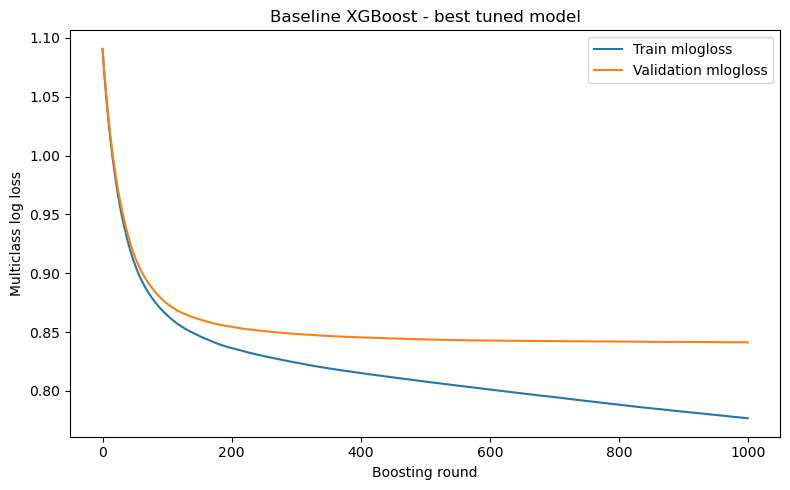

In [20]:
# plot the learning curve of the best tuned baseline model

plot_xgb_learning_curve(
    baseline_best_tuned_model,
    title="Baseline XGBoost - best tuned model"
)

In [21]:
# evaluate the tuned baseline model on validation

baseline_val_results, y_val_pred_baseline_xgb, y_val_prob_baseline_xgb = evaluate_model_on_split(
    baseline_best_tuned_model,
    baseline_tuned_preprocessor,
    X_val_baseline,
    y_val,
    baseline_features_cols,
    split_name="validation"
)

display(pd.DataFrame([baseline_val_results]))

,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,validation,0.606568,0.555571,0.600818,0.458713,0.502445,0.841164


In [22]:
# retrain on train/val

X_trainval_baseline = pd.concat([X_train_baseline, X_val_baseline], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

baseline_preprocessor_final, baseline_xgb_final, y_test_pred_baseline_xgb, y_test_prob_baseline_xgb = train_final_xgb(
    X_trainval_df=X_trainval_baseline,
    y_trainval=y_trainval,
    X_test_df=X_test_baseline,
    feature_cols=baseline_features_cols,
    categorical_cols=baseline_categorical_cols,
    best_params=baseline_best_params,
    best_iteration=baseline_best_iteration,
    random_state=42
)

## HIERARCHICAL MODEL

In [23]:
# BASELINE MODEL: HYPERPARAMETER TUNING ON TRAIN/VAL

hier_tuning_results, hier_best_params, hier_best_iteration, hier_best_tuned_model, hier_tuned_preprocessor = tune_xgb_multiclass(
    X_train_df=X_train_hierarchical,
    y_train=y_train,
    X_val_df=X_val_hierarchical,
    y_val=y_val,
    feature_cols=hierarchical_features_cols,
    categorical_cols=hierarchical_categorical_cols,
    param_grid=param_grid,
    random_state=42
)

display(hier_tuning_results.head(20))

print("Best hierarchical params:")
print(hier_best_params)
print("Best hierarchical iteration:", hier_best_iteration)

,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_lambda,subsample,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss,best_iteration
0,0.8,0.03,4,5,3.0,0.8,validation,0.606434,0.556255,0.599753,0.458445,0.503666,0.836983,962
1,0.8,0.05,4,3,3.0,0.8,validation,0.607239,0.555973,0.600132,0.458043,0.503811,0.837137,542
2,0.8,0.03,4,5,1.0,0.8,validation,0.606568,0.555760,0.600069,0.457909,0.503909,0.836186,962
3,0.8,0.05,5,3,1.0,0.8,validation,0.607641,0.555590,0.601203,0.454021,0.508821,0.835208,514
4,1.0,0.03,4,5,3.0,0.8,validation,0.606032,0.555215,0.600084,0.458311,0.503587,0.837023,962
5,0.8,0.03,4,3,3.0,0.8,validation,0.607239,0.555123,0.600049,0.458311,0.504213,0.837885,779
6,0.8,0.03,4,1,3.0,0.8,validation,0.605898,0.555057,0.599135,0.459249,0.503148,0.836501,962
7,0.8,0.10,4,1,3.0,1.0,validation,0.606836,0.555044,0.600072,0.461394,0.496753,0.839848,307
8,1.0,0.03,4,5,1.0,0.8,validation,0.605898,0.554973,0.599930,0.458713,0.503362,0.836817,962
9,1.0,0.05,5,3,1.0,0.8,validation,0.607105,0.554951,0.599899,0.456434,0.506848,0.835396,408


Best hierarchical params:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 5, 'reg_lambda': 3.0, 'subsample': 0.8}
Best hierarchical iteration: 962


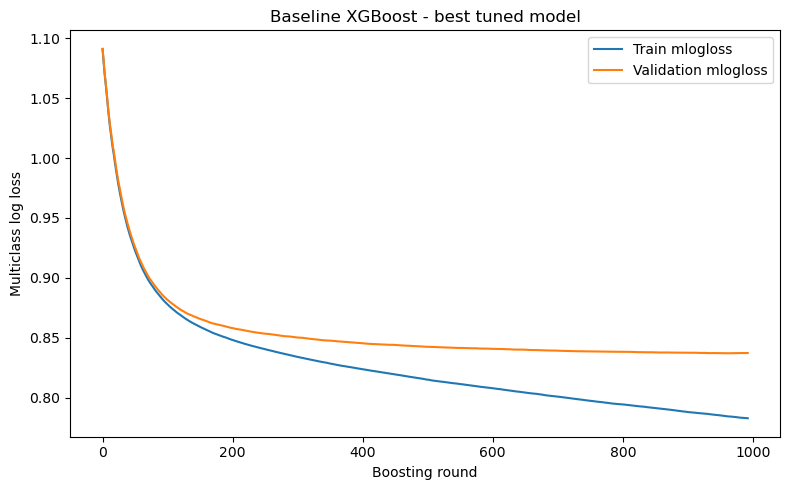

In [24]:
# plot the learning curve of the best tuned hierarchical model

plot_xgb_learning_curve(
    hier_best_tuned_model,
    title="Baseline XGBoost - best tuned model"
)

In [25]:
# evaluate the tuned baseline model on validation

hierarchical_val_results, y_val_pred_hier_xgb, y_val_prob_hier_xgb = evaluate_model_on_split(
    hier_best_tuned_model,
    hier_tuned_preprocessor,
    X_val_hierarchical,
    y_val,
    hierarchical_features_cols,
    split_name="validation"
)

display(pd.DataFrame([hierarchical_val_results]))

,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,validation,0.606434,0.556255,0.599753,0.458445,0.503666,0.836983


In [26]:
# retrain on train/val

X_trainval_hierarchical = pd.concat([X_train_hierarchical, X_val_hierarchical], axis=0)

hierarchical_preprocessor_final, hierarchical_xgb_final, y_test_pred_hier_xgb, y_test_prob_hier_xgb = train_final_xgb(
    X_trainval_df=X_trainval_hierarchical,
    y_trainval=y_trainval,
    X_test_df=X_test_hierarchical,
    feature_cols=hierarchical_features_cols,
    categorical_cols=hierarchical_categorical_cols,
    best_params=hier_best_params,
    best_iteration=hier_best_iteration,
    random_state=42
)

# 5) Evaluation strategy

We evaluate each model on the test set.

This is a binary classification so for both models, metrics are:
 
- macro F1
- quadratic weighted kappa

For comparison between the two models (to answer the question "does the hierarchy model outperform the baseline model"), we use:

- the difference between the two F1 scores

**VISUALIZATION:**

- feature importance / SHAP plot for hierarchy features

In [27]:
# BASELINE MODEL: evaluate once on test set, show confusion matrix

baseline_test_results = evaluate_predictions(
    y_test,
    y_test_pred_baseline_xgb,
    y_test_prob_baseline_xgb,
    split_name="test"
)

display(pd.DataFrame([baseline_val_results, baseline_test_results]))

class_labels = ["difficulty", "moderate_success", "strong_success"]

cm_test_baseline_xgb = confusion_matrix(y_test, y_test_pred_baseline_xgb, labels=[0, 1, 2])

cm_test_baseline_xgb_df = pd.DataFrame(
    cm_test_baseline_xgb,
    index=[f"true_{c}" for c in class_labels],
    columns=[f"pred_{c}" for c in class_labels]
)

display(cm_test_baseline_xgb_df)

,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,validation,0.606568,0.555571,0.600818,0.458713,0.502445,0.841164
1,test,0.562659,0.526217,0.568165,0.525801,0.451587,0.899056


,pred_difficulty,pred_moderate_success,pred_strong_success
true_difficulty,754,266,124
true_moderate_success,838,938,735
true_strong_success,536,764,2506


In [28]:
# HIERARCHICAL MODE: evaluate once on test set, show confusion matrix

hierarchical_test_results = evaluate_predictions(
    y_test,
    y_test_pred_hier_xgb,
    y_test_prob_hier_xgb,
    split_name="test"
)

display(pd.DataFrame([hierarchical_val_results, hierarchical_test_results]))

cm_test_hier_xgb = confusion_matrix(y_test, y_test_pred_hier_xgb, labels=[0, 1, 2])

cm_test_hier_xgb_df = pd.DataFrame(
    cm_test_hier_xgb,
    index=[f"true_{c}" for c in class_labels],
    columns=[f"pred_{c}" for c in class_labels]
)

display(cm_test_hier_xgb_df)

,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,validation,0.606434,0.556255,0.599753,0.458445,0.503666,0.836983
1,test,0.571505,0.535933,0.577331,0.518697,0.455938,0.892017


,pred_difficulty,pred_moderate_success,pred_strong_success
true_difficulty,771,246,127
true_moderate_success,828,973,710
true_strong_success,546,740,2520


# 6) Analysis of results

Now, we want to understand why the metrics of the hierarchical model do not improve that much

In [29]:
# comparison of the two models

comparison_df = pd.DataFrame([
    baseline_val_results,
    baseline_test_results,
    hierarchical_val_results,
    hierarchical_test_results
])

display(comparison_df)

,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,validation,0.606568,0.555571,0.600818,0.458713,0.502445,0.841164
1,test,0.562659,0.526217,0.568165,0.525801,0.451587,0.899056
2,validation,0.606434,0.556255,0.599753,0.458445,0.503666,0.836983
3,test,0.571505,0.535933,0.577331,0.518697,0.455938,0.892017


We observe that there is a very weak increase in F1 score. Therefore, we decide to study feature importance on the hierarchical model to understand whether the added sibling-history features are actually being used by the model and whether they contribute some signal beyond the baseline features.

,feature,importance
73,num__subject_math,0.145161
80,num__prior_subject_accuracy,0.046899
1,cat__child_topic_id_951.0,0.030538
51,cat__child_topic_id_3112.0,0.028363
48,cat__child_topic_id_2065.0,0.024630
46,cat__child_topic_id_2055.0,0.024442
3,cat__child_topic_id_956.0,0.024137
52,cat__child_topic_id_3113.0,0.023938
69,cat__child_topic_id_3320.0,0.022574
49,cat__child_topic_id_3110.0,0.021502


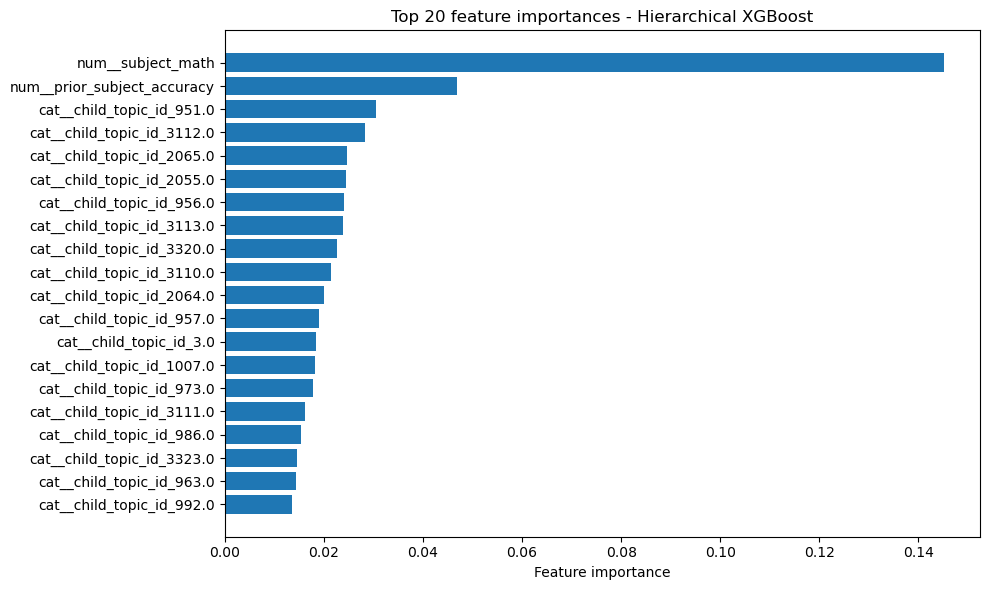

In [31]:
# feature importance of the hierarchical model

feature_names_hier = hier_tuned_preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    "feature": feature_names_hier,
    "importance": hier_best_tuned_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importances.head(20))

plt.figure(figsize=(10, 6))
top20 = importances.head(20)
plt.barh(top20["feature"][::-1], top20["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Top 20 feature importances - Hierarchical XGBoost")
plt.tight_layout()
plt.show()

It seems like a large part of the predictive signal comes from topic-specific effects (the figure above shows a lot of child_topic_id features being important for the model's splits). This is plausible because different child topics likely differ in several important ways, such as in:

- their intrinsic difficulty
- their style/format of questions
- the type of students typically reaching them
- and, more generally, how “easy” it is to get 0/3, 2/3, or 3/3 correct on first entry into the topic

In other words, the model appears to learn that some topics are inherently more likely than others to lead to difficulty, moderate success, or strong success at entry.

At the same time, none of the sibling-based features appear in the top 20 most important features. This suggests that sibling history contributes much less to prediction than topic identity and other strong baseline factors. So, although sibling information may add a small amount of signal, the model is driven mainly by which topic is being entered, rather than by past practice on sibling topics.

In [34]:
# Get feature names from the fitted hierarchical preprocessor

# Build importance table
importances_hier = pd.DataFrame({
    "feature": feature_names_hier,
    "importance": hier_best_tuned_model.feature_importances_
}).sort_values("importance", ascending=False)

# Keep only sibling-related features
sibling_importances = importances_hier[
    importances_hier["feature"].str.contains("sibling", case=False, na=False)
].copy()

print("Sibling feature importances:")
display(sibling_importances)

Sibling feature importances:


,feature,importance
86,num__prop_siblings_seen,0.006812
89,num__prop_sibling_topics_entered_before,0.005015
88,num__prior_sibling_accuracy_30d,0.004931
84,num__prior_sibling_accuracy,0.004923
92,num__n_prior_sibling_attempts_last3,0.004630
87,num__n_prior_sibling_attempts_30d,0.004378
90,num__is_first_topic_in_sibling_group,0.004299
85,num__days_since_last_sibling_activity,0.004179
91,num__prior_sibling_accuracy_last3,0.004154
83,num__n_prior_sibling_attempts,0.003992


In [35]:
# Inspect sibling groups: parent topic + nb of child topics in the group

all_groups = (
    lookup_table.groupby(["parent_id", "parent_name"])
    .size()
    .reset_index(name="n_topics_in_group")
    .sort_values("n_topics_in_group", ascending=False)
)

display(all_groups.head(20))
print(all_groups.shape)

,parent_id,parent_name,n_topics_in_group
3,985.0,Equations,10
1,950.0,Numbers and number sets,9
2,969.0,Terms,6
7,1058.0,Trigonometry,6
12,3107.0,Sets,6
4,1006.0,Functions,5
5,1030.0,Elementary geometry,5
10,3105.0,Word types,5
0,2.0,Orthography,4
8,2022.0,Vocabulary and stylistics,4


(14, 3)
